Se han cargado 204 tweets con éxito.
              precision    recall  f1-score   support

   Blackpink       0.78      0.88      0.82         8
  Elden Ring       0.90      0.75      0.82        12
   Fórmula 1       1.00      0.83      0.91         6
      MotoGP       0.76      0.87      0.81        15

    accuracy                           0.83        41
   macro avg       0.86      0.83      0.84        41
weighted avg       0.84      0.83      0.83        41



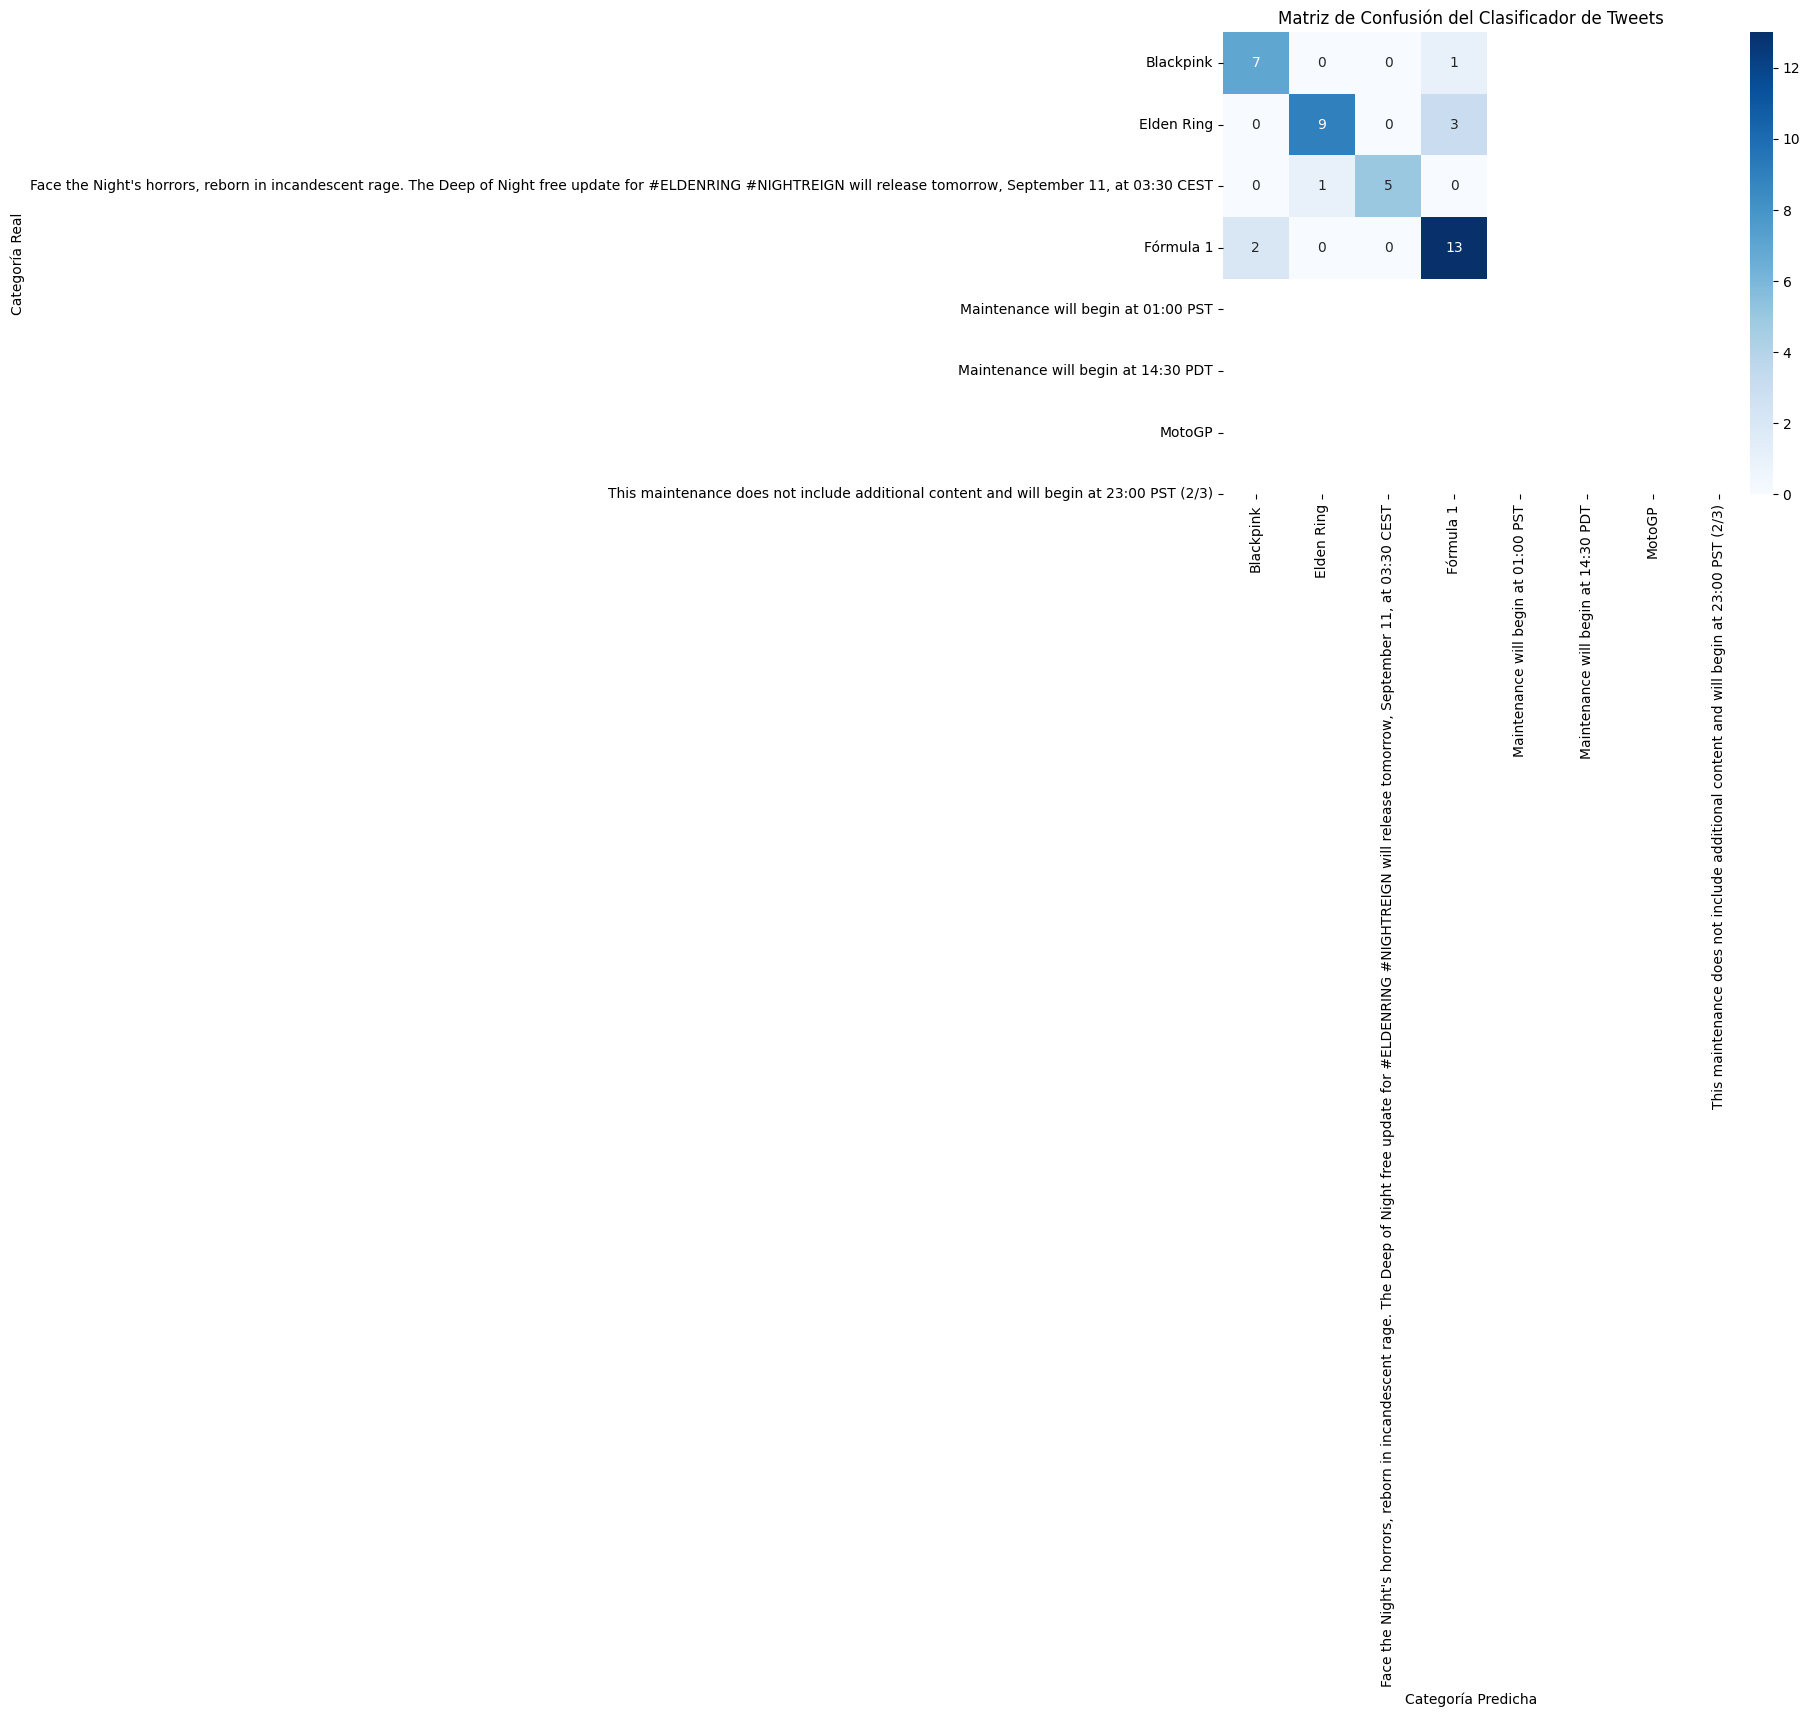

In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Descargar stopwords en INGLÉS (ya que los tweets están en este idioma)
nltk.download('stopwords', quiet=True) # Ponemos quiet=True para ocultar los logs
stop_words_en = set(stopwords.words('english'))

# 2. Cargar los datos de forma segura controlando los separadores
datos = []

# Asegurarse de que el nombre del archivo coincide exactamente
with open('Tweets.txt', 'r', encoding='utf-8') as archivo:
    for linea in archivo:
        linea = linea.strip() # Quitar saltos de línea y espacios en los extremos

        # Si la línea contiene al menos un separador '|'
        if '|' in linea:
            # El parámetro "1" le indica a Python que divida solo en el PRIMER '|'
            partes = linea.split('|', 1)
            categoria = partes[0].strip()
            tweet = partes[1].strip()

            # Solo guardamos si realmente hay texto en el tweet
            if tweet:
                datos.append([categoria, tweet])

# Crear el DataFrame de Pandas a partir de la lista limpia
df = pd.DataFrame(datos, columns=['categoria', 'tweet'])

# Comprobar cuántos tweets se han cargado correctamente
print(f"Se han cargado {len(df)} tweets con éxito.")

# 3. Función de preprocesamiento avanzado
def limpiar_texto(texto):
    texto = texto.lower() # Convertir a minúsculas
    texto = re.sub(r'http\S+', '', texto) # Quitar enlaces
    texto = re.sub(r'@\w+', '', texto) # Quitar menciones
    texto = re.sub(r'#\w+', '', texto) # Quitar hashtags

    # ELIMINAR caracteres no ASCII (quitará emojis, y caracteres en coreano/japonés
    # que introducen ruido en el modelo para este caso concreto)
    texto = re.sub(r'[^\x00-\x7F]+', ' ', texto)

    texto = re.sub(r'[^\w\s]', '', texto) # Quitar signos de puntuación restantes

    # Quitar stopwords en inglés
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words_en]

    return ' '.join(palabras)

# Aplicar la limpieza
df['tweet_limpio'] = df['tweet'].apply(limpiar_texto)

# 4. Partición de datos (80% entrenamiento, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df['tweet_limpio'], df['categoria'], test_size=0.2, random_state=42)

# 5. Indexación con TF-IDF usando unigramas y bigramas
# NOTA : Usar bigramas es clave para detectar términos como "pole position" o "world tour"
# AJUSTE PARA MEJORAR EL MODELO: min_df=3 elimina palabras que aparecen en menos de 3 tweets (ruido)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=2000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 6. Entrenamiento del modelo SVM ajustado
# (Volvemos a dejar C=1.0 porque el ajuste lo hemos hecho en el vectorizador)
modelo_svm = SVC(kernel='linear', C=1.0)
modelo_svm.fit(X_train_tfidf, y_train)

# 7. Evaluación y Métricas
y_pred = modelo_svm.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

# Matriz de confusión visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_svm.classes_,
            yticklabels=modelo_svm.classes_)
plt.title('Matriz de Confusión del Clasificador de Tweets')
plt.ylabel('Categoría Real')
plt.xlabel('Categoría Predicha')
plt.show()